# Convert individual sources to MEI

**CAMAT workflow 2 of 4: convert sources to MEI.** See `docs/overview.md` for the complete workflow map and `docs/guides/formats.md` for the companion guide.

This notebook answers one question: **how does one source become the MEI document that CAMAT parses?** It uses real public scores selected from the repository's `test_corpus/*.txt` manifests. It does not generate toy MusicXML, Humdrum, MIDI, or MuseScore files.

The examples require an internet connection. Converted MEI is written to the gitignored `converted_mei/single_file_tutorial/` directory; the remote source and its URL remain the provenance record.

In [1]:
from pathlib import Path
from urllib.parse import urlparse
import os
import sys

import pandas as pd
from IPython.display import display

# Find the checkout whether Jupyter started in the repo root or notebooks/.
_here = Path.cwd().resolve()
ROOT = next(
    (path for path in (_here, *_here.parents) if (path / 'camat' / '__init__.py').is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError('Run this notebook from a CAMAT source checkout.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from camat import (
    __version__,
    convert_sources,
    expand_file_sources,
    parse_files,
    vrv_convert_to_mei,
    vrv_display_svg,
    vrv_guess_input_from,
    vrv_load_from_file,
    vrv_quiet,
    vrv_render_page,
    vrv_set_options,
)

NON_MEI_MANIFEST = ROOT / 'test_corpus' / 'non_mei_test_copora_links.txt'
MEI_MANIFEST = ROOT / 'test_corpus' / 'mei_test_copora_links.txt'
OUTPUT_DIR = ROOT / 'converted_mei' / 'single_file_tutorial'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_NETWORK_EXAMPLES = os.environ.get('CAMAT_RUN_NETWORK_EXAMPLES', '1').lower() not in {'0', 'false', 'no'}

print('CAMAT:', __version__)
print('Repository:', ROOT)
print('Output:', OUTPUT_DIR)
print('Network examples:', RUN_NETWORK_EXAMPLES)

CAMAT: 0.1.13
Repository: /home/eggi/Nextcloud/code/public_repos/camat_v2
Output: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/single_file_tutorial
Network examples: True


## Select sources from the corpus manifests

`expand_file_sources(...)` accepts direct URLs, local score paths, or a local `.txt` file containing any mixture of those forms. Blank lines and `#` comments are ignored. Here the local inputs are the two manifest files; their score entries are remote raw-file URLs.

The examples are selected by recognizable path fragments rather than copied into the notebook. The manifests therefore remain the canonical source lists. A `.xml` suffix is intentionally ambiguous; CAMAT determines MEI versus MusicXML from the downloaded content.

In [2]:
non_mei_sources = expand_file_sources([str(NON_MEI_MANIFEST)], base_dir=ROOT, verbose=False)
mei_sources = expand_file_sources([str(MEI_MANIFEST)], base_dir=ROOT, verbose=False)

def select_source(sources, fragment):
    return next(source for source in sources if fragment in source)

SOURCES = {
    'MEI (parse directly)': select_source(mei_sources, 'Aguado_Walzer_G-major.mei'),
    'Humdrum (convert directly)': select_source(non_mei_sources, 'sonata14-1.krn'),
    'MusicXML (convert directly)': select_source(non_mei_sources, 'Schubert_D911-07.xml'),
    'MIDI (music21 bridge)': select_source(non_mei_sources, 'Bach/Prelude/bwv_846/midi_score.mid'),
}
PLANNED_ROUTES = {
    'MEI (parse directly)': 'parse directly',
    'Humdrum (convert directly)': 'verovio-direct',
    'MusicXML (convert directly)': 'verovio-direct',
    'MIDI (music21 bridge)': 'music21-musicxml-verovio',
}

source_rows = []
for role, source in SOURCES.items():
    source_rows.append({
        'role': role,
        'filename': Path(urlparse(source).path).name,
        'verovio_input_guess': vrv_guess_input_from(source),
        'planned_route': PLANNED_ROUTES[role],
        'source': source,
    })
display(pd.DataFrame(source_rows))

,role,filename,verovio_input_guess,planned_route,source
0,MEI (parse directly),Aguado_Walzer_G-major.mei,mei,parse directly,https://raw.githubusercontent.com/music-encodi...
1,Humdrum (convert directly),sonata14-1.krn,humdrum,verovio-direct,https://raw.githubusercontent.com/craigsapp/be...
2,MusicXML (convert directly),Schubert_D911-07.xml,NaN,verovio-direct,https://raw.githubusercontent.com/piasteuck/wi...
3,MIDI (music21 bridge),midi_score.mid,NaN,music21-musicxml-verovio,https://raw.githubusercontent.com/fosfrancesco...


## Route 1 — already MEI: parse directly

A common-notation MEI source does not need conversion. Passing its raw URL to `parse_files(...)` downloads a working copy, parses it with the default Verovio backend, and preserves the URL in the result record.

In [3]:
if not RUN_NETWORK_EXAMPLES:
    direct_mei_results = []
    print('Skipped: CAMAT_RUN_NETWORK_EXAMPLES=0')
else:
    direct_mei_results, _, direct_mei_df_pitch = parse_files(
        [SOURCES['MEI (parse directly)']],
        backend='none',
        display_preview_df_pitch=False,
        display_preview_df_events=False,
        include_xml_ids=True,
        show_progress=False,
        quiet_native_warnings=True,
    )
    print('Parser backend:', direct_mei_results[0]['parser_backend'])
    print('Pitch rows:', len(direct_mei_df_pitch))
    display(direct_mei_df_pitch.head())

Processing (verovio): Aguado_Walzer_G-major.mei -> 00_aguado_walzer_g_major
Extracted non-barline MEI events: 52 event(s), types=['annot', 'direction', 'measure', 'tempo', 'tie'].
Parser backend: verovio
Pitch rows: 123


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,0.00,0.00,1.50,G4,67,P1 - Voice 2,d30278e178,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.50,<NA>
1,1,0.00,0.00,1.50,B4,71,P1 - Voice 2,d30278e193,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.50,<NA>
2,1,0.50,0.50,0.25,B5,83,P1 - Voice 1,d30278e96,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.25,<NA>
3,1,0.75,0.75,0.25,C6,84,P1 - Voice 1,d30278e118,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.25,<NA>
4,1,1.00,1.00,0.50,D6,86,P1 - Voice 1,d30278e140,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.50,<NA>


## Route 2 — Verovio-native source: convert directly

MusicXML and Humdrum are native Verovio inputs. `vrv_convert_to_mei(...)` accepts each raw URL with `is_url=True` and returns MEI text. Saving that text creates the explicit hand-off artifact for parsing.

The helper also accepts a local path: omit `is_url=True` and pass something like `path/to/score.musicxml`. The conversion itself is otherwise the same.

,source,input_from,output_mei,mei_characters
0,https://raw.githubusercontent.com/craigsapp/be...,humdrum,/home/eggi/Nextcloud/code/public_repos/camat_v...,285054
1,https://raw.githubusercontent.com/piasteuck/wi...,NaN,/home/eggi/Nextcloud/code/public_repos/camat_v...,511107


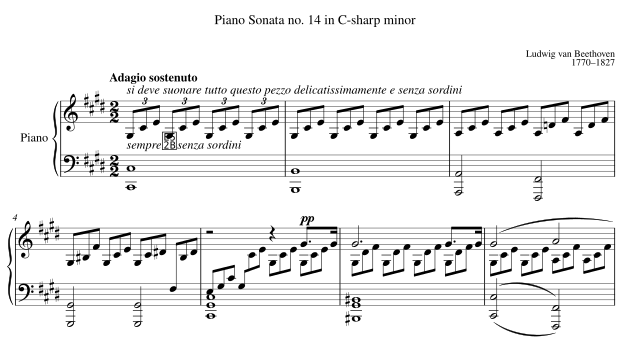

In [4]:
def convert_url_to_mei(source_url, label):
    with vrv_quiet():
        vrv_set_options(
            pageWidth=2100,
            pageHeight=1200,
            scale=30,
            breaks='auto',
            removeIds=False,
        )
        mei_text = vrv_convert_to_mei(source_url, is_url=True, timeout=90)
        preview_svg = vrv_render_page(1)

    source_stem = Path(urlparse(source_url).path).stem
    output_path = OUTPUT_DIR / f'{source_stem}_{label}.mei'
    output_path.write_text(mei_text, encoding='utf-8')
    return {
        'source': source_url,
        'input_from': vrv_guess_input_from(source_url),
        'output_mei': output_path,
        'mei_characters': len(mei_text),
        'preview_svg': preview_svg,
    }

conversion_records = []
if not RUN_NETWORK_EXAMPLES:
    print('Skipped: CAMAT_RUN_NETWORK_EXAMPLES=0')
else:
    conversion_records = [
        convert_url_to_mei(SOURCES['Humdrum (convert directly)'], 'from_humdrum'),
        convert_url_to_mei(SOURCES['MusicXML (convert directly)'], 'from_musicxml'),
    ]
    display(pd.DataFrame([
        {key: value for key, value in record.items() if key != 'preview_svg'}
        for record in conversion_records
    ]))
    vrv_display_svg(conversion_records[0]['preview_svg'])

## Routes 3 and 4 — bridge formats

Two routes need a tool before Verovio:

| Source | Route | Why it is separate |
| --- | --- | --- |
| MIDI or another music21-only format | music21 → MusicXML → Verovio → MEI | music21 reconstructs notation before Verovio creates the analysis MEI |
| `.mscz` / `.mscx` | MuseScore → MusicXML → Verovio → MEI | Verovio does not read MuseScore's native format |

The next cell executes the installed `camat.convert_sources(...)` MIDI route with a real ASAP score selected from the canonical manifest. CAMAT imports MIDI on a `(8, 6, 4, 3)` quantization grid so straight 32nds and triplets survive, then separates staggered overlaps into voices and fills their gaps with visible rests. Without the latter step, the delayed lower-staff E in BWV 846 is flattened into one MEI layer. The downloaded MIDI and intermediate MusicXML are working files, not generated tutorial examples. MuseScore conversion remains in the batch notebook because it depends on an external CLI; a missing executable is reported as a route-specific failure.

,source,status,input_from,local_source,output_mei,converted,overwritten,message,error,intermediate_musicxml,...,page_count,output_chars,svg_ok,verovio_version,xml_id_count,duplicate_xml_id_count,note_count,rest_count,measure_count,mei_version
0,https://raw.githubusercontent.com/fosfrancesco...,ok,midi,/home/eggi/Nextcloud/code/public_repos/camat_v...,/home/eggi/Nextcloud/code/public_repos/camat_v...,True,True,"Converted source to MusicXML with music21, the...",None,/home/eggi/Nextcloud/code/public_repos/camat_v...,...,2,169779,True,6.2.1-8d42439,1605,0,549,132,35,6.0-dev


,quantization_quarter_length_divisors,staggered_overlap_measures,voice_measures_before,voice_measures_after,visible_rests_added
0,"[8, 6, 4, 3]",34,0,34,66


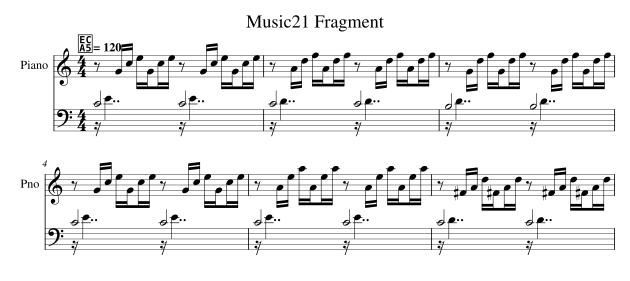

In [5]:
def convert_midi_url_to_mei(source_url):
    record = convert_sources(
        [source_url],
        output_dir=OUTPUT_DIR,
        n_jobs=1,
        show_progress=False,
    )[0]
    if record.get('status') != 'ok':
        raise RuntimeError(record.get('error') or 'MIDI conversion failed')

    with vrv_quiet():
        vrv_set_options(
            pageWidth=2100,
            pageHeight=1200,
            scale=30,
            breaks='auto',
            removeIds=False,
        )
        vrv_load_from_file(record['output_mei'], input_from='mei')
        preview_svg = vrv_render_page(1)

    return {**record, 'preview_svg': preview_svg}

if not RUN_NETWORK_EXAMPLES:
    print('Skipped: CAMAT_RUN_NETWORK_EXAMPLES=0')
else:
    midi_record = convert_midi_url_to_mei(SOURCES['MIDI (music21 bridge)'])
    conversion_records.append(midi_record)
    display(pd.DataFrame([{
        key: value for key, value in midi_record.items() if key != 'preview_svg'
    }]))
    display(pd.DataFrame([midi_record['music21_diagnostics']]))
    vrv_display_svg(midi_record['preview_svg'])

## Validate the hand-off by parsing the converted MEI

Successful conversion means more than receiving a non-empty string. Parse the saved `.mei`, retain its source URL, and inspect note rows and identifiers before analysis.

In [6]:
if not conversion_records:
    converted_results = []
    print('No converted MEI to parse.')
else:
    converted_paths = [str(record['output_mei']) for record in conversion_records]
    converted_results, converted_dfs, _ = parse_files(
        converted_paths,
        backend='none',
        display_preview_df_pitch=False,
        display_preview_df_events=False,
        include_xml_ids=True,
        show_progress=False,
        quiet_native_warnings=True,
    )
    validation_rows = []
    for result, conversion in zip(converted_results, conversion_records):
        df_pitch = result['df_pitch']
        validation_rows.append({
            'source': Path(urlparse(conversion['source']).path).name,
            'output_mei': Path(conversion['output_mei']).name,
            'pitch_rows': len(df_pitch),
            'event_rows': len(result['df_events']),
            'xml_id_rows': int(df_pitch['xml_id'].notna().sum()),
        })
    display(pd.DataFrame(validation_rows))

Processing (verovio): sonata14-1_from_humdrum.mei -> 00_sonata14_1_from_humdrum


Extracted non-barline MEI events: 202 event(s), types=['clef', 'direction', 'dynamic', 'fermata', 'hairpin', 'key_sig', 'measure', 'meter_sig', 'mrest', 'slur', 'space', 'tempo', 'tie'].

Processing (verovio): Schubert_D911-07_from_musicxml.mei -> 01_schubert_d911_07_from_musicxml


Extracted non-barline MEI events: 475 event(s), types=['arpeg', 'artic', 'clef', 'direction', 'dynamic', 'fermata', 'hairpin', 'key_sig', 'lyric', 'measure', 'meter_sig', 'slur', 'tempo', 'tie'].

Processing (verovio): midi_score_896268229c29_midi_verovio.mei -> 02_midi_score_896268229c29_midi_verovio


Extracted non-barline MEI events: 42 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'tempo'].


,source,output_mei,pitch_rows,event_rows,xml_id_rows
0,sonata14-1.krn,sonata14-1_from_humdrum.mei,1169,225,1169
1,Schubert_D911-07.xml,Schubert_D911-07_from_musicxml.mei,1330,725,1330
2,midi_score.mid,midi_score_896268229c29_midi_verovio.mei,549,174,549


## What this notebook produced

- one MEI URL parsed without conversion;
- one Humdrum URL converted directly by Verovio;
- one MusicXML URL converted directly by Verovio;
- one MIDI URL converted through music21 → MusicXML → Verovio;
- saved MEI files under `converted_mei/single_file_tutorial/`;
- a parsing smoke test linking each converted file to `df_pitch`, `df_events`, and `xml_id`.

Next: use `camat_batch_conversion.ipynb` for source lists, mixed routes, crash isolation, and a persistent conversion report.